Import Libraries

In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

Configuration & Data Paths

In [9]:
IMG_SIZE = 224
MAX_FRAMES = 30
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 5e-4

# Update these paths
DATASET_DIR = r"C:\Users\rahif\OneDrive\Desktop\DeepFake Detection\CombinedDataset"
REAL_DIR = r"C:\Users\rahif\OneDrive\Desktop\DeepFake Detection\CombinedDataset\Real"
FAKE_DIR = r"C:\Users\rahif\OneDrive\Desktop\DeepFake Detection\CombinedDataset\Fake"
MODEL_SAVE_PATH = 'deepfake.h5'

print("Configuration Loaded")

Configuration Loaded


Face Detection + Cropping

In [10]:
def detect_and_crop_face(frame, target_size=(IMG_SIZE, IMG_SIZE)):
    """Detect face and crop + resize. Fallback to full frame if no face."""
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
    
    if len(faces) > 0:
        # Take the first (largest) face
        x, y, w, h = faces[0]
        face = frame[y:y+h, x:x+w]
    else:
        face = frame  # fallback
    
    # Resize and normalize
    face = cv2.resize(face, target_size)
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    face = face.astype(np.float32) / 255.0
    
    return face

Extract Frames with Face Preprocessing

In [11]:
def extract_frames(video_path, max_frames=MAX_FRAMES):
    """Extract frames with face detection and preprocessing"""
    cap = cv2.VideoCapture(video_path)
    frames = []
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        cap.release()
        return np.zeros((max_frames, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
    
    step = max(1, total_frames // max_frames)
    
    count = 0
    while len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
            
        if count % step == 0:
            processed_face = detect_and_crop_face(frame)
            frames.append(processed_face)
        
        count += 1
    
    cap.release()
    
    # Pad with zeros if video is too short
    while len(frames) < max_frames:
        frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32))
    
    return np.array(frames[:max_frames], dtype=np.float32)

LOAD DATASET

In [12]:
def load_data(max_videos_per_class=500):
    X, y = [], []
    
    # Real videos
    real_videos = [os.path.join(REAL_DIR, f) for f in os.listdir(REAL_DIR) 
                   if f.endswith(('.mp4', '.avi', '.mov'))][:max_videos_per_class]
    
    for path in tqdm(real_videos, desc="Loading REAL videos"):
        frames = extract_frames(path)
        X.append(frames)
        y.append(0)  # 0 = Real
    
    # Fake videos
    fake_videos = [os.path.join(FAKE_DIR, f) for f in os.listdir(FAKE_DIR) 
                   if f.endswith(('.mp4', '.avi', '.mov'))][:max_videos_per_class]
    
    for path in tqdm(fake_videos, desc="Loading FAKE videos"):
        frames = extract_frames(path)
        X.append(frames)
        y.append(1)  # 1 = Fake
    
    return np.array(X), np.array(y)

In [13]:
import random

def load_video_paths(max_videos_per_class=500):
    """Load only paths and labels - very memory efficient"""
    video_paths = []
    labels = []

    for label, class_name in enumerate(['Real', 'Fake']):
        folder = os.path.join(DATASET_DIR, class_name)
        if not os.path.exists(folder):
            print(f"Warning: Folder not found - {folder}")
            continue
            
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))]
        
        if max_videos_per_class:
            files = files[:max_videos_per_class]
        
        for file in files:
            video_paths.append(os.path.join(folder, file))
            labels.append(label)

    print(f"Total videos loaded: {len(video_paths)} (Real: {labels.count(0)}, Fake: {labels.count(1)})")
    return video_paths, np.array(labels)

Data Generator

In [14]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, video_paths, labels, batch_size=BATCH_SIZE, shuffle=True):
        self.video_paths = video_paths
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.video_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_paths = self.video_paths[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_labels = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]

        X_batch = []
        y_batch = []

        for path, label in zip(batch_paths, batch_labels):
            frames = extract_frames(path)
            X_batch.append(frames)
            y_batch.append(label)

        return np.array(X_batch, dtype=np.float32), np.array(y_batch, dtype=np.int32)

    def on_epoch_end(self):
        if self.shuffle:
            # Shuffle data at end of each epoch
            temp = list(zip(self.video_paths, self.labels))
            random.shuffle(temp)
            self.video_paths, self.labels = zip(*temp)

Model Build ResNet + LSTM

In [15]:
def build_model():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False  # Freeze CNN layers
    
    inputs = Input(shape=(MAX_FRAMES, IMG_SIZE, IMG_SIZE, 3))
    
    x = tf.keras.layers.TimeDistributed(base_model)(inputs)
    x = tf.keras.layers.TimeDistributed(GlobalAveragePooling2D())(x)
    
    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.3)(x)
    x = LSTM(64)(x)
    x = Dropout(0.3)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

Estract Video Feature

In [17]:
def extract_video_features(video_path):

    cap = cv2.VideoCapture(video_path)

    frames = []
    MAX_FRAMES = 30  # or less for speed

    while len(frames) < MAX_FRAMES:

        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (224, 224))
        frame = frame / 255.0  # normalize

        frames.append(frame)

    cap.release()

    # padding if video short
    while len(frames) < MAX_FRAMES:
        frames.append(np.zeros((224, 224, 3)))

    return np.array(frames)

Main Equation

In [18]:
print("Starting Deepfake Detection Project...")

video_paths, y = load_video_paths(max_videos_per_class=1000)

train_paths, test_paths, y_train, y_test = train_test_split(
    video_paths, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train videos: {len(train_paths)} | Test videos: {len(test_paths)}")

train_gen = DataGenerator(train_paths, y_train, batch_size=64, shuffle=True)
test_gen = DataGenerator(test_paths, y_test, batch_size=64, shuffle=False)

model = build_model()

callbacks = [
    ModelCheckpoint('deepfake.h5', save_best_only=True, monitor='val_accuracy'),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Starting Deepfake Detection Project...
Total videos loaded: 2000 (Real: 1000, Fake: 1000)
Train videos: 1600 | Test videos: 400
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 277s/step - accuracy: 0.5187 - loss: 0.7141  

25/25 ━━━━━━━━━━━━━━━━━━━━ 9967s 392s/step - accuracy: 0.5106 - loss: 0.7101 - val_accuracy: 0.5225 - val_loss: 0.6923 - learning_rate: 5.0000e-04
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 342s/step - accuracy: 0.5076 - loss: 0.7107  

25/25 ━━━━━━━━━━━━━━━━━━━━ 12230s 486s/step - accuracy: 0.5038 - loss: 0.7074 - val_accuracy: 0.5550 - val_loss: 0.6890 - learning_rate: 5.0000e-04
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10544s 427s/step - accuracy: 0.5231 - loss: 0.6936 - val_accuracy: 0.5225 - val_loss: 0.6939 - learning_rate: 5.0000e-04
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 9233s 373s/step - accuracy: 0.5113 - loss: 0.6981 - val_accuracy: 0.5000 - val_loss: 0.6911 - learning_rate: 5.0000e-04
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 9697s 393s/step - accuracy: 0.5219 - loss: 0.6946 - val_accuracy: 0.5000 - val_loss: 0.6947 - learning_rate: 5.0000e-04


Evaluation

In [19]:
print("Evaluating model...")

y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred))

Evaluating model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 2259s 291s/step
              precision    recall  f1-score   support

           0       0.56      0.51      0.53       200
           1       0.55      0.59      0.57       200

    accuracy                           0.55       400
   macro avg       0.55      0.55      0.55       400
weighted avg       0.55      0.55      0.55       400



Scatter Plot of Prediction Results

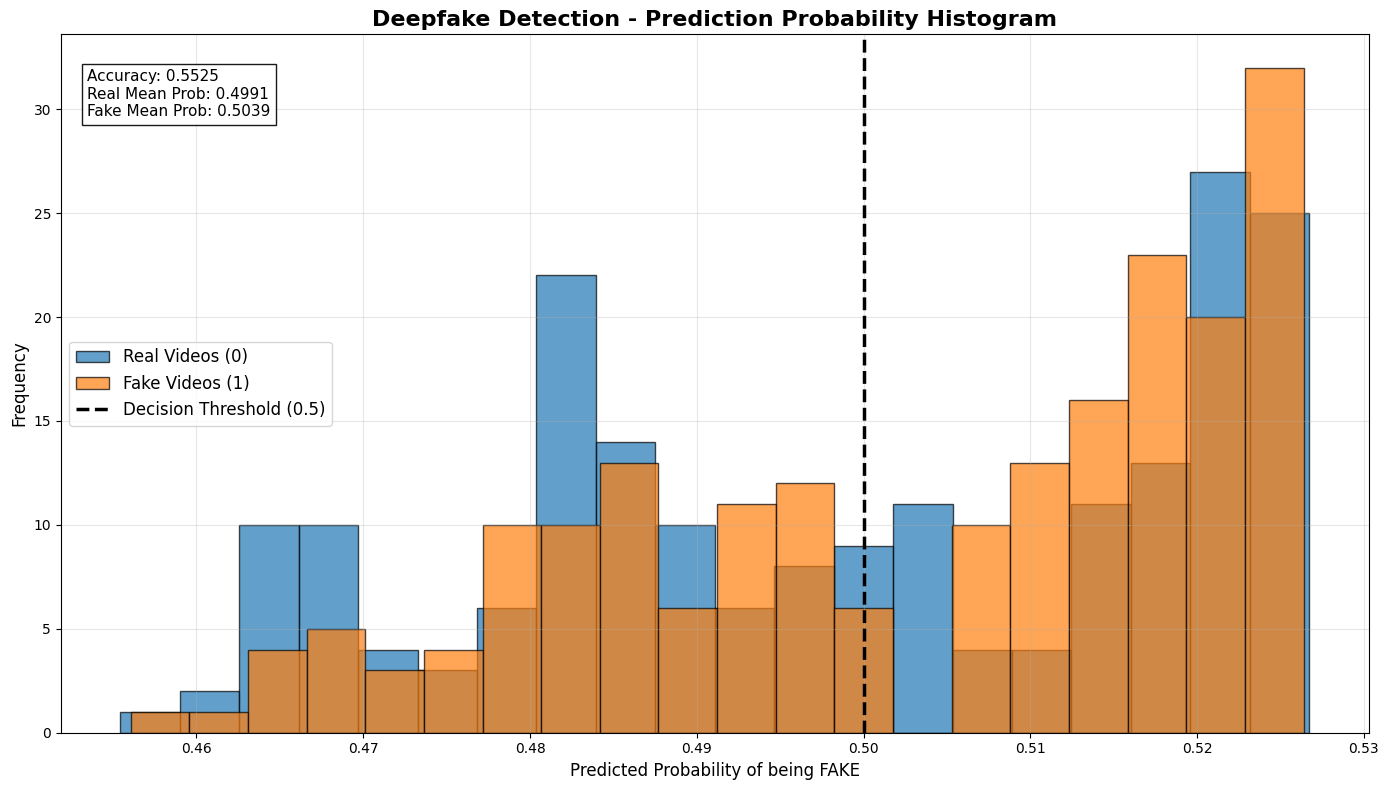

In [21]:
plt.figure(figsize=(14, 8))

# Separate real and fake predictions
real_probs = y_pred_prob[y_test == 0].flatten()
fake_probs = y_pred_prob[y_test == 1].flatten()

# Histogram for Real videos
plt.hist(real_probs, bins=20, alpha=0.7,
         label='Real Videos (0)',
         edgecolor='black')

# Histogram for Fake videos
plt.hist(fake_probs, bins=20, alpha=0.7,
         label='Fake Videos (1)',
         edgecolor='black')

# Threshold line
plt.axvline(x=0.5, color='black', linestyle='--',
            linewidth=2.5, label='Decision Threshold (0.5)')

# Titles and labels
plt.title('Deepfake Detection - Prediction Probability Histogram',
          fontsize=16, fontweight='bold')

plt.xlabel('Predicted Probability of being FAKE', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Accuracy text box
accuracy = np.mean((y_pred_prob > 0.5).astype(int).flatten() == y_test)

plt.text(0.02, 0.95,
         f'Accuracy: {accuracy:.4f}\n'
         f'Real Mean Prob: {real_probs.mean():.4f}\n'
         f'Fake Mean Prob: {fake_probs.mean():.4f}',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'),
         fontsize=11,
         verticalalignment='top')

plt.tight_layout()
plt.show()

Confusion Matrix

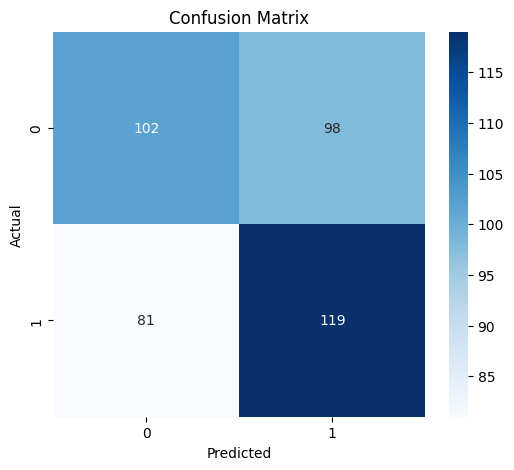

In [22]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

INFERENCE FUNCTION

In [24]:
def predict_video(video_path):
    frames = extract_frames(video_path)
    frames = np.expand_dims(frames, axis=0)
    pred = model.predict(frames)[0][0]
    label = "FAKE" if pred > 0.5 else "REAL"
    confidence = pred if pred > 0.5 else (1 - pred)
    print(f"\nVideo: {video_path}")
    print(f"Prediction: {label} ({confidence*100:.2f}% confidence)")
    return label, confidence

In [28]:
# Test on new video
predict_video(r"C:\Users\rahif\OneDrive\Desktop\DeepFake Detection\REAL1.mp4")# Test on new video

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Video: C:\Users\rahif\OneDrive\Desktop\DeepFake Detection\REAL1.mp4
Prediction: REAL (51.28% confidence)


('REAL', np.float32(0.5127528))

In [31]:
# Test on new video
predict_video(r"C:\Users\rahif\OneDrive\Desktop\DeepFake Detection\REAL2.mp4")# Test on new video

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Video: C:\Users\rahif\OneDrive\Desktop\DeepFake Detection\REAL2.mp4
Prediction: REAL (50.48% confidence)


('REAL', np.float32(0.5048194))

In [26]:
predict_video(r"C:\Users\rahif\OneDrive\Desktop\DeepFake Detection\CombinedDataset\Fake\german_fake_Fake_1993.mp4")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Video: C:\Users\rahif\OneDrive\Desktop\DeepFake Detection\CombinedDataset\Fake\german_fake_Fake_1993.mp4
Prediction: FAKE (51.73% confidence)


('FAKE', np.float32(0.51728404))